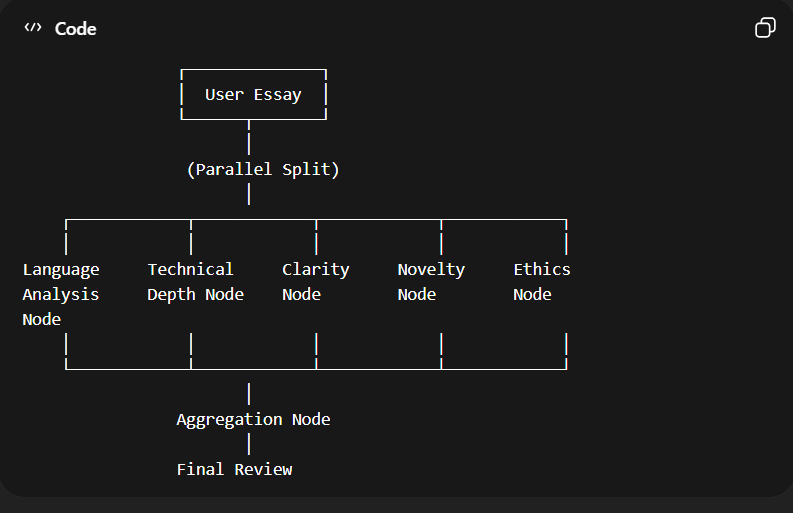

In [1]:
OPENAI_API_KEY="your api key"

In [2]:
!pip install langchain langchain_openai pydantic langgraph

In [3]:
from langchain_openai import ChatOpenAI

In [5]:
from pydantic import BaseModel, Field

In [8]:
class EvaluationSchema(BaseModel):
  feedback:str =  Field(description='Detailed feedback for essay')
  score: int = Field(description='Score out of 10', ge=0, le=10)

In [9]:
llm = ChatOpenAI(model='gpt-4o-mini', api_key=OPENAI_API_KEY)
structured_model = llm.with_structured_output(EvaluationSchema)

In [41]:
Essay_Sample = """
Essay: Current Situation in Pakistan (with mistakes)
Pakistan is facing many problems in the present time and the situation is becoming more challenging day by day. The country economy is not stable and inflation rate are increasing very fast which is creating difficulties for the common peoples. Prices of daily use items like flour, petrol, electricity and vegetables has been increased and it is becoming hard for middle class families to survive in such condition.
One of the major issue in Pakistan is unemployment. Many educated students is completing their degrees but they are not able to find a suitable jobs in the market. This is creating frustration among the youth and sometime it leads toward negative activities. Government are trying to make new policies but their implementation is not effective enough to control the situation.
Political instability is also a big reason behind the current crisis. Different political parties is blaming each other instead of working together for the betterment of the country. Due to this instability, foreign investors are not interested to invest in Pakistan which is effecting the economic growth badly.
Energy crisis is another serious problem that peoples are facing. Load shedding of electricity and gas are disturbing the daily life routines as well as industrial sector. Many factories has been closed due to shortage of energy resources which ultimately increase the unemployment rate in the country.
In conclusion, Pakistan is going through a difficult phase and it need serious attention from both government and citizens. If proper steps will not be taken on time then the situation may become more worst in the future. Everyone should play their role for the development and stability of Pakistan.
"""

In [11]:
prompt = f'evaluate the essay and feedback it:\n {Essay_Sample}'

In [ ]:
response = structured_model.invoke(prompt)

In [ ]:

print(response.feedback[:100])
print(response.score)

In [19]:
from typing import TypedDict, Annotated
import operator

In [53]:
class EssayState(TypedDict):
  essay:str
  language_feedback:str
  depth_feedback: str
  clarity_feedback: str
  novelty_feedback: str
  ethics_feedback: str
  individual_score: Annotated[list[int], operator.add]
  avg_score: float
  final_summary:str

In [73]:
#language node
def evaluate_language(state:EssayState):
  prompt = f'evaluate the essay language and give feedback and score out of 10 Essay: \n {state['essay']}'
  output = structured_model.invoke(prompt)

  return {'language_feedback':output.feedback, 'individual_score':[output.score]}

In [74]:
#depth node
def evaluate_depth(state:EssayState):
  prompt = f'evaluate the essay technical depth and give feedback and score out of 10 Essay: \n {state['essay']}'
  output = structured_model.invoke(prompt)

  return {'depth_feedback':output.feedback, 'individual_score':[output.score]}

In [75]:
#clarity node
def evaluate_clarity(state:EssayState):
  prompt = f'evaluate the essay clarity and give feedback and score out of 10 Essay: \n {state['essay']}'
  output = structured_model.invoke(prompt)

  return {'clarity_feedback':output.feedback, 'individual_score':[output.score]}

In [76]:
#novelty node
def evaluate_novelty(state:EssayState):
  prompt = f'evaluate the essay Novelty and give feedback and score out of 10 Essay: \n {state['essay']}'
  output = structured_model.invoke(prompt)

  return {'novelty_feedback':output.feedback, 'individual_score':[output.score]}

In [77]:
#ethics node
def evaluate_ethics(state:EssayState):
  prompt = f'evaluate the essay ethics and give feedback and score out of 10 Essay: \n {state['essay']}'
  output = structured_model.invoke(prompt)

  return {'ethics_feedback':output.feedback, 'individual_score':[output.score]}

In [78]:
#final summary node
def evalute_final_summary(state:EssayState):
  avg_score = sum(state['individual_score']) /len(state['individual_score'])

  prompt =  f"""
  you are a final evaluate generate a final summarized feedback based on these:
  \n -language feedback: {state['language_feedback']} \n
  -depth feedback: {state['depth_feedback']} \n
  -clarity feedback: {state['clarity_feedback']} \n
  -novelty feedback: {state['novelty_feedback']} \n
  -ehtics feedback: {state['ethics_feedback']}
  """
  output = llm.invoke(prompt).content

  return {'final_summary': output, 'avg_score': avg_score}

In [79]:
from langgraph.graph import StateGraph, START, END

In [80]:
graph = StateGraph(EssayState)

#define nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_depth', evaluate_depth)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('evaluate_novelity', evaluate_novelty)
graph.add_node('evaluate_ethics', evaluate_ethics)
graph.add_node('final_summary', evalute_final_summary)

#define edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_depth')
graph.add_edge(START, 'evaluate_clarity')
graph.add_edge(START, 'evaluate_novelity')
graph.add_edge(START, 'evaluate_ethics')

graph.add_edge('evaluate_language', 'final_summary')
graph.add_edge('evaluate_depth', 'final_summary')
graph.add_edge('evaluate_clarity', 'final_summary')
graph.add_edge('evaluate_novelity', 'final_summary')
graph.add_edge('evaluate_ethics', 'final_summary')

graph.add_edge('final_summary', END)

workflow = graph.compile()

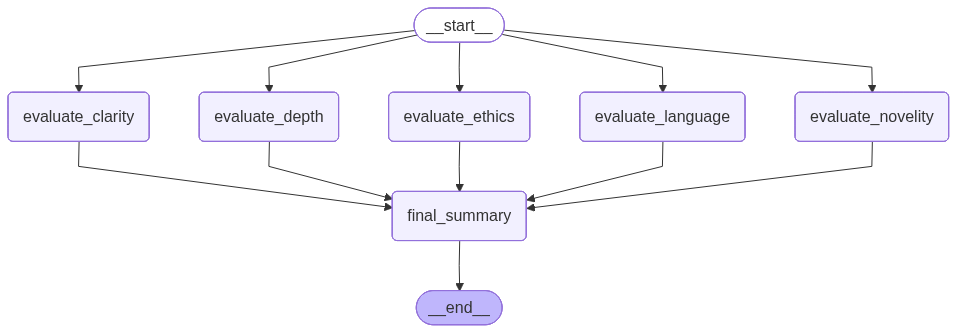

In [81]:
workflow

In [88]:
essay_sample = """Artificial Intelligence (AI) has rapidly evolved from a theoretical concept into a transformative technology that is reshaping industries, economies, and societies worldwide. From healthcare diagnostics to financial forecasting, AI systems are increasingly being used to automate complex decision-making processes that were traditionally performed by humans. While the efficiency and scalability of AI-driven solutions offer significant advantages, their growing integration into critical sectors also raises important concerns regarding transparency, accountability, and ethical governance.

One of the most promising applications of AI can be observed in the healthcare sector, where machine learning models assist in early disease detection by analyzing medical imaging and patient records. Such systems have the potential to reduce diagnostic errors and improve treatment outcomes by identifying patterns that may not be immediately visible to human practitioners. However, the reliability of these systems is highly dependent on the quality and diversity of the training data used during model development. Biased or incomplete datasets may lead to discriminatory outcomes, thereby reinforcing existing social inequalities instead of mitigating them.

In addition to healthcare, AI technologies are playing an increasingly influential role in educational environments through personalized learning platforms. These systems aim to adapt educational content based on individual learning styles and performance metrics, thereby enhancing student engagement and knowledge retention. Nevertheless, excessive reliance on automated educational tools may reduce opportunities for critical thinking and interpersonal interaction, both of which are essential components of holistic learning.

Furthermore, the deployment of AI in governance and surveillance frameworks has sparked debates about privacy and civil liberties. While intelligent monitoring systems can enhance public safety by identifying potential threats in real time, their misuse may result in unwarranted intrusion into personal freedoms. Therefore, it is essential to establish comprehensive regulatory frameworks that ensure the responsible and transparent use of AI technologies.

In conclusion, Artificial Intelligence presents both unprecedented opportunities and complex challenges. Its successful implementation requires a balanced approach that prioritizes innovation while safeguarding ethical standards and social equity. By fostering interdisciplinary collaboration among technologists, policymakers, and ethicists, society can harness the benefits of AI while minimizing its potential risks.
"""

In [89]:
initial_state = {
    'essay': Essay_Sample
}


In [90]:
response = workflow.invoke(initial_state)

/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback... correctness.', score=5), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback... Impact: 4/10', score=4), input_type=EvaluationSchema])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=EvaluationSchema(feedback.

In [91]:
response['final_summary']

'### Final Summarized Feedback\n\nThe essay addresses pressing issues in Pakistan, including economic instability, unemployment, political challenges, and energy crises. While it successfully highlights these significant topics and calls for action, several areas require substantial improvement to enhance both clarity and impact.\n\n**Strengths:**\n- The essay identifies key issues and articulates the urgency of addressing them, demonstrating a commendable awareness of the national context.\n- It concludes with a general call to action, emphasizing the necessity for collaboration.\n\n**Areas for Improvement:**\n\n1. **Grammar and Syntax:** Numerous grammatical errors, including subject-verb agreement and incorrect pluralization, detract from the professionalism of the writing. For example, sentences like "The country economy is not stable" need to be corrected to "The country\'s economy is not stable."\n\n2. **Clarity and Conciseness:** Many sentences are convoluted or too lengthy. Sho

In [92]:
response['individual_score']

[5, 4, 5, 5, 4]